# CTGF calcium imaging_Activity episodes, co-fluctuation and directionality
By Debora Masini, 2024

This notebook is used to identify and analyse neuronal activity episodes, co-fluctuating pairs, and the directionality of co-fluctuating pairs.

### Step 1) Identify activity episodes for each cell present on day 1 (= session 1 of the open field).
This segment loads a calcium-imaging trace, applies a high-pass filter, computes robust amplitude thresholds using the median absolute deviation, and masks low-amplitude fluctuations. The remaining high-pass signal is converted to its sign to identify positive and negative excursions. Consecutive positive or negative samples are grouped into runs, and only those lasting longer than the minimum duration (defined from the sampling rate and a millisecond threshold) are retained as upward or downward episodes. The script produces plots showing the raw trace, filtered trace, masked trace, and detected episodes.

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [ ]:
# HP filter → MAD threshold on HP amplitude → mask → sign → duration filter via MIN_MS.

# From one file; select a cell and a time period as an example for analysis
file_idx = 0; cell_idx = 3; t0, t1 = 0, 4200
directory = r"...\python_analysis_results"
csv_files = sorted([f for f in os.listdir(directory) if f.startswith("FINAL_") and f.endswith(".csv")]) # calcium signal files from Inscopix

# SAMPLING / FILTER
FS = 10.0 # Inscopix at 10Hz
HP_CUTOFF = 0.01 # Filter
MAD_SCALE = 2.0; MAD_FLOOR_PERCENTILE = 5; ABS_EPS_MIN = 1e-3 # threshold for detection of ups and downs

# EPISODE RULES
MIN_MS = 300
MIN_FRAMES = int(np.ceil((MIN_MS/1000) * FS))
MIN_UP = MIN_FRAMES
MIN_DOWN = MIN_FRAMES

def hp(x): 
    b,a = butter(2,HP_CUTOFF/(FS/2),'high')
    return filtfilt(b,a,x,axis=0)

# Compute eps...because the algorithm needs a data-dependent amplitude threshold used to decide which parts of the signal are “real” deviations and which are noise.
def compute_eps(x): 
    mad_vals, eps_i = [], []
    for col in x.T:
        med = np.median(col)
        m = np.median(np.abs(col-med))
        eps_i.append(MAD_SCALE*m)
        if np.isfinite(m) and m>0: mad_vals.append(m)
    floor = np.percentile(mad_vals,MAD_FLOOR_PERCENTILE) if len(mad_vals)>0 else ABS_EPS_MIN
    return np.array(eps_i), max(floor,ABS_EPS_MIN)

def count_runs(arr):
    runs=[]; inrun=False; s=0
    for i,v in enumerate(arr):
        if v and not inrun: inrun=True; s=i
        if not v and inrun: inrun=False; runs.append((s,i-1))
    if inrun: runs.append((s,len(arr)-1))
    return runs

# LOAD
path = os.path.join(directory,csv_files[file_idx])
df = pd.read_csv(path).drop(columns=['Time (s)'],errors='ignore').dropna(axis=1,how='all')
tr = df.to_numpy()

# PROCESSING: raw → HP → MAD → masked HP → sign
hp_tr = hp(tr)
eps_i, eps_floor = compute_eps(hp_tr)
mask_hp = np.zeros_like(hp_tr)

for i in range(hp_tr.shape[1]):
    eps = eps_i[i] if np.isfinite(eps_i[i]) and eps_i[i]>0 else eps_floor
    eps = max(eps,eps_floor,ABS_EPS_MIN)
    mask_hp[:,i] = np.abs(hp_tr[:,i]) >= eps

hp_clean = hp_tr * mask_hp
sign = np.sign(hp_clean)     # sign directly from masked HP

# extract neuron
raw = tr[:,cell_idx]
hp1 = hp_tr[:,cell_idx]
hp_c = hp_clean[:,cell_idx]
sg = sign[:,cell_idx]
eps_val = eps_i[cell_idx] if np.isfinite(eps_i[cell_idx]) and eps_i[cell_idx]>0 else eps_floor

# window
if t0 is not None and t1 is not None:
    raw = raw[t0:t1]
    hp1 = hp1[t0:t1]
    hp_c = hp_c[t0:t1]
    sg = sg[t0:t1]

# sign → upward & downward episodes
up0 = count_runs(sg>0)
down0 = count_runs(sg<0)
up_runs=[(s,e) for s,e in up0 if (e-s+1)>=MIN_UP]
down_runs=[(s,e) for s,e in down0 if (e-s+1)>=MIN_DOWN]
print("Up episodes:", len(up_runs), " Down episodes:", len(down_runs))
# Duration up and down episodes
up_durs = [(e - s + 1) for s, e in up_runs]
down_durs = [(e - s + 1) for s, e in down_runs]

sg_clean = np.zeros_like(sg)
for s,e in up_runs: sg_clean[s:e+1]=+1
for s,e in down_runs: sg_clean[s:e+1]=-1
frame_ms = 1000 / FS
print("Mean up duration (ms):", np.mean(up_durs)*frame_ms if len(up_durs)>0 else 0)
print("Mean down duration (ms):", np.mean(down_durs)*frame_ms if len(down_durs)>0 else 0)

# PLOT for visual inspection
plt.figure(figsize=(15,10))
plt.subplot(4,1,1); plt.plot(raw,color='grey'); plt.title(f"L6b-Ctgf; Raw calcium trace — file {file_idx}, cell {cell_idx}")
plt.subplot(4,1,2); plt.plot(hp1,color='black'); plt.title(f"step 1: High-pass filtered calcium signal (2nd-order Butterworth, 0.01Hz), dashed = MAD threshold {MAD_SCALE}")
plt.axhline(+eps_val,color='r',ls='--',alpha=0.5)
plt.axhline(-eps_val,color='r',ls='--',alpha=0.5)
plt.subplot(4,1,3)
#plt.plot(hp1,color='black')
plt.plot(hp_c,color='blue', alpha=0.5); plt.title("step 2: High-pass filtered calcium signal after threshold masking")
plt.subplot(4,1,4)
#plt.plot(sg_clean,linewidth=2); 
plt.plot(raw,color='grey')
for s,e in up_runs: plt.axvspan(s,e,color='green',alpha=0.25)
for s,e in down_runs: plt.axvspan(s,e,color='red',alpha=0.15)
plt.title("step 3: Detected episodes with increase or decrease of signal (sign +1-green or -1 red) overlay on filtered trace")
plt.tight_layout(); plt.show()


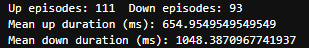

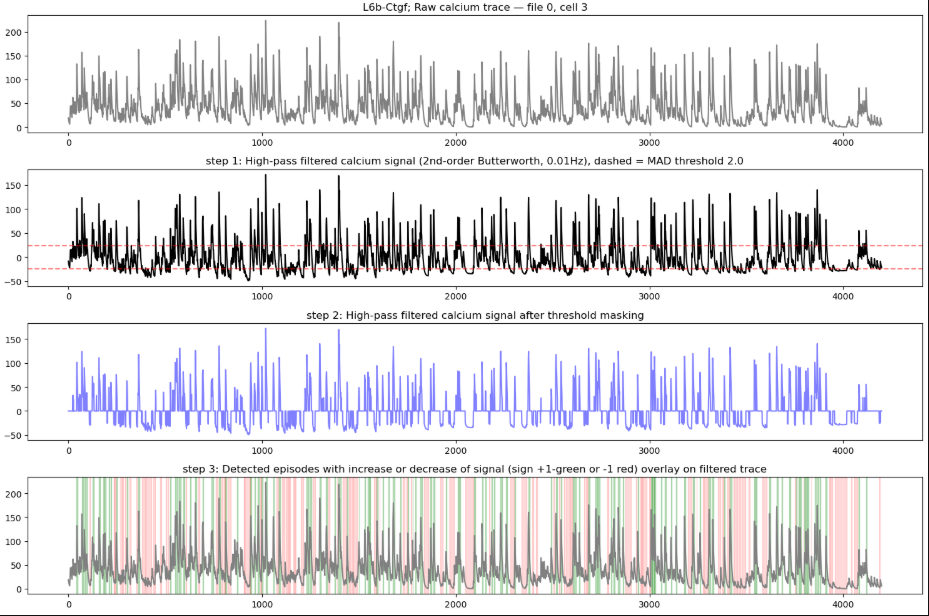

In [ ]:
# Step 1 ends, clear all variables
%reset -f
print("memory clean!")

# -----------------------------------------------------------------
## Step 2) Build episode sign sequences per neuron (Day 1) and quantify pairwise co-fluctuation with surrogate control

This step takes each Day-1 calcium trace matrix (T frames × N neurons) and converts it into a sparse episode sign matrix (sign_mat) that only marks sustained positive/negative excursions (as example above). It then computes, for every neuron pair, how often their detected episodes overlap in the same direction (↑↑ or ↓↓) versus opposite directions (↑↓ or ↓↑), and assesses significance using circular-shift surrogates with an FDR-ready output.


The **circular-shift surrogate**  is a null version of the data created by randomly circularly shifting each node’s (ie, cell) sign time series independently and then recomputing the same pairwise statistic.
- Starts with sign_mat shaped (T, N) (time × node).
- For each surrogate draw:
  - For each node i, pick shift ~ Uniform{0, …, Tm1-1}...Set sign_surr[:, i] = roll(sign_mat[:, i], shift)
  - So each node keeps: the same values (-1/0/+1) and overall counts, the same autocorrelation structure up to circular wrap, but destroys cross-node alignment / synchrony because shifts are independent across nodes.
  - Interpretation: the surrogate distribution is your estimate of what cofluct fractions you’d expect if nodes had the same individual sign dynamics but no true time-locked coupling between nodes.
  - literature: Schreiber & Schmitz (2000) – “Surrogate time series” https://www.sciencedirect.com/science/article/pii/S0167278900000439

In [ ]:
import os, numpy as np, pandas as pd
from scipy.signal import butter, filtfilt
from scipy.stats import norm

In [1]:
print("SciPy:", scipy.__version__)

SciPy: 1.13.1


In [ ]:

directory = r'...\python_analysis_results'
analysis_folder = os.path.join(directory, 'results')
os.makedirs(analysis_folder, exist_ok=True)

FS = 10.0; MS_PER_FRAME = 1000.0 / FS
HP_CUTOFF = 0.01
MAD_SCALE = 2.0; MAD_FLOOR_PERCENTILE = 5; ABS_EPS_MIN = 1e-3

# EPISODE RULES (to give sign)
MIN_MS = 300
MIN_FRAMES = int(np.ceil(MIN_MS / MS_PER_FRAME)); MIN_UP = MIN_FRAMES; MIN_DOWN = MIN_FRAMES

# cofluctuation rules (pairwise)
# These two rules are used inside compute_cofluct, and they control whether a neuron pair is considered to have stable cofluctuation before the script calculates the fraction of same-direction episodes.
MIN_RUN_LENGTH = 2 # co-fluctuate for at least 200ms, of that 300ms window
MIN_STABLE_PROP = 0.01 # cover minimum of 1% of the video *full video 20min

# control for false discovery
N_SURR = 1000; FDR_Q_LEVELS = [0.05, 0.01] # q>0.01 is the one used in the article, very restrictive

def highpass_filter(data):
    b,a = butter(2, HP_CUTOFF/(FS/2), 'high')
    return filtfilt(b, a, data, axis=0)

def compute_epsilons(x):
    N = x.shape[1]
    mad_vals = []; eps_i = np.zeros(N)
    for i in range(N):
        col = x[:,i]
        med = np.median(col)
        mad = np.median(np.abs(col - med))
        eps = MAD_SCALE * mad
        eps_i[i] = eps
        if np.isfinite(eps) and eps > 0:
            mad_vals.append(mad)
    eps_floor = np.percentile(mad_vals, MAD_FLOOR_PERCENTILE) if len(mad_vals)>0 else ABS_EPS_MIN
    return eps_i, max(eps_floor, ABS_EPS_MIN)

def apply_threshold(x, eps_i, eps_floor):
    thr = np.zeros_like(x)
    for i in range(x.shape[1]):
        eps = eps_i[i] if np.isfinite(eps_i[i]) and eps_i[i] > 0 else eps_floor
        col = x[:,i]
        thr[:,i] = col * (np.abs(col) >= eps)
    return thr

def count_runs(arr):
    runs = []; inrun=False; s=0
    for i, v in enumerate(arr):
        if v and not inrun:
            inrun=True; s = i
        if not v and inrun:
            inrun=False; runs.append((s, i-1))
    if inrun: runs.append((s, len(arr)-1))
    return runs

# unified cofluctuation on sign sequences
def compute_cofluct(s1, s2, Tm1):
    valid = (s1 != 0) & (s2 != 0) # A frame is “valid” only if both neurons have a episode on the same frame. Direction does not matter.
    if np.sum(valid) == 0: return None
    runs = []; r = 0
    for v in valid:
        if v: r += 1
        else:
            if r>0: runs.append(r)
            r = 0
    if r>0: runs.append(r)
    long_frames = sum(x for x in runs if x >= MIN_RUN_LENGTH) # Overlapping episodes shorter than 200ms are discarded.
    if long_frames < MIN_STABLE_PROP * Tm1: return None # MIN_STABLE_PROP = 0.01 ... cover minimum of 1% of the video
    v1, v2 = s1[valid], s2[valid]
    su = np.sum((v1>0) & (v2>0)) # +1/+1
    sd = np.sum((v1<0) & (v2<0)) # -1/-1
    same = su + sd
    opp = np.sum((v1>0)&(v2<0)) + np.sum((v1<0)&(v2>0)) # up-down +down-up...opposite directions
    tot = same + opp
    if tot == 0: return None
    return same/tot, su, sd

csv_files = [f for f in os.listdir(directory) if f.startswith('FINAL_') and f.endswith('.csv') and 'Day1' in f] # only for Day 1 = session 1, 20min empty open field
for file_name in csv_files:
    print(f"\nProcessing {file_name}...")
    df = pd.read_csv(os.path.join(directory, file_name)).drop(columns=['Time (s)'], errors='ignore').dropna(axis=1, how='all')
    if df.shape[1] < 2:
        print("  Skipped"); continue
    traces = df.to_numpy()
    T, N = traces.shape
    
    hp_tr = highpass_filter(traces)
    Tm1 = hp_tr.shape[0]
    
    eps_i, eps_floor = compute_epsilons(hp_tr)
    thr = apply_threshold(hp_tr, eps_i, eps_floor)

    # EPISODE-BASED SIGN per neuron
    sign_mat = np.zeros_like(thr)
    for i in range(N):
        col = thr[:,i]
        up_raw = col > 0
        down_raw = col < 0
        up_runs = count_runs(up_raw)
        down_runs = count_runs(down_raw)
        for s,e in up_runs:
            if (e - s + 1) >= MIN_UP:
                sign_mat[s:e+1, i] = +1
        for s,e in down_runs:
            if (e - s + 1) >= MIN_DOWN:
                sign_mat[s:e+1, i] = -1

    base = file_name.replace('.csv','')
    np.save(os.path.join(analysis_folder, f"{base}_sign_matrix.npy"), sign_mat) # only has sign on the rows that pass the threshold and the time filter...

    # per-neuron up/down probabilities
    p_up = np.zeros(N); p_down = np.zeros(N)
    for i in range(N):
        s = sign_mat[:,i]
        valid = (s!=0)
        if np.sum(valid)==0:
            p_up[i]=np.nan; p_down[i]=np.nan
        else:
            v = s[valid]
            p_up[i] = np.sum(v>0)/len(v)
            p_down[i] = np.sum(v<0)/len(v)

    same_frac = np.full((N,N), np.nan)
    expected_same = np.full((N,N), np.nan)
    same_up = np.full((N,N), np.nan)
    same_down = np.full((N,N), np.nan)
    opp_frac = np.full((N,N), np.nan) # opposite-direction fractions
    
    # OBSERVED COFLUCT
    for i in range(N):
        for j in range(i,N):
            if i==j:
                same_frac[i,i]=1.0; continue
            out = compute_cofluct(sign_mat[:,i], sign_mat[:,j], Tm1)
            if out is None: continue
            frac, su, sd = out
            
            same_frac[i,j] = same_frac[j,i] = frac
            same_up[i,j] = same_up[j,i] = su
            same_down[i,j] = same_down[j,i] = sd
            # opposite-direction fraction to the calculation
            valid = (sign_mat[:,i]!=0) & (sign_mat[:,j]!=0)
            v1, v2 = sign_mat[valid, i], sign_mat[valid, j]
            su = np.sum((v1>0)&(v2>0)); sd = np.sum((v1<0)&(v2<0))
            same = su + sd
            opp = np.sum((v1>0)&(v2<0)) + np.sum((v1<0)&(v2>0))
            tot = same + opp
            opp_frac[i,j] = opp_frac[j,i] = opp/tot if tot>0 else np.nan
            
            if not (np.isnan(p_up[i]) or np.isnan(p_up[j])):
                expected_same[i,j] = expected_same[j,i] = p_up[i]*p_up[j] + p_down[i]*p_down[j]

    # SURROGATES (takes time to run)
    print("  Surrogates...")
    mean_null = np.zeros((N,N)); m2_null = np.zeros((N,N)); c_null=np.zeros((N,N),int)
    mean_null_opp = np.zeros((N,N)); m2_null_opp=np.zeros((N,N)); c_null_opp=np.zeros((N,N),int)
    obs_mask = np.isfinite(same_frac)
    rng = np.random.default_rng()

    for _ in range(N_SURR):
        sign_surr = np.empty_like(sign_mat)
        for i in range(N):
            shift = rng.integers(0, Tm1)
            sign_surr[:,i] = np.roll(sign_mat[:,i], shift)
        for i in range(N):
            s1 = sign_surr[:,i]
            for j in range(i+1,N):
                if not obs_mask[i,j]: continue
                out = compute_cofluct(s1, sign_surr[:,j], Tm1)
                if out is None: continue
                frac,_,_ = out
                c = c_null[i,j]
                c_new = c + 1
                delta = frac - mean_null[i,j]
                mean_null[i,j] += delta / c_new
                m2_null[i,j] += delta * (frac - mean_null[i,j])
                c_null[i,j] = c_new

                # opposite-direction surrogate
                s1v = s1!=0;  s2v = sign_surr[:,j]!=0
                valid = s1v & s2v
                v1, v2 = s1[valid], sign_surr[:,j][valid]
                su = np.sum((v1>0)&(v2>0)); sd = np.sum((v1<0)&(v2<0))
                same = su + sd
                opp = np.sum((v1>0)&(v2<0)) + np.sum((v1<0)&(v2>0))
                tot = same + opp
                if tot>0:
                    frac_opp = opp/tot
                    c=c_null_opp[i,j]; c_new=c+1
                    d=frac_opp-mean_null_opp[i,j]
                    mean_null_opp[i,j]+=d/c_new
                    m2_null_opp[i,j]+=d*(frac_opp-mean_null_opp[i,j])
                    c_null_opp[i,j]=c_new

    for i in range(N):
        for j in range(i+1,N):
            mean_null[j,i]=mean_null[i,j]
            m2_null[j,i]=m2_null[i,j]
            c_null[j,i]=c_null[i,j]
    for i in range(N):
        for j in range(i+1,N):
            mean_null_opp[j,i]=mean_null_opp[i,j]
            m2_null_opp[j,i]=m2_null_opp[i,j]
            c_null_opp[j,i]=c_null_opp[i,j]
        
    var_null = np.where(c_null>1, m2_null/(c_null-1), np.nan)
    z = np.where(np.isfinite(var_null), (same_frac-mean_null)/np.sqrt(var_null), np.nan)
    var_null_opp = np.where(c_null_opp>1, m2_null_opp/(c_null_opp-1), np.nan)
    z_opp = np.where(np.isfinite(var_null_opp), (opp_frac-mean_null_opp)/np.sqrt(var_null_opp), np.nan)

    pd.DataFrame(same_frac, index=df.columns, columns=df.columns).to_csv(os.path.join(analysis_folder, f"{base}_samefrac_obs.csv"))
    pd.DataFrame(mean_null,index=df.columns, columns=df.columns).to_csv(os.path.join(analysis_folder, f"{base}_samefrac_nullmean.csv"))
    pd.DataFrame(expected_same,index=df.columns, columns=df.columns).to_csv(os.path.join(analysis_folder, f"{base}_expected_same_symmetric_analytic.csv"))
    pd.DataFrame(z,index=df.columns, columns=df.columns).to_csv(os.path.join(analysis_folder, f"{base}_zscore_surrogate.csv"))
    pd.DataFrame(same_up,index=df.columns, columns=df.columns).to_csv(os.path.join(analysis_folder, f"{base}_same_up_counts.csv"))
    pd.DataFrame(same_down,index=df.columns, columns=df.columns).to_csv(os.path.join(analysis_folder, f"{base}_same_down_counts.csv"))

    pd.DataFrame(opp_frac,index=df.columns,columns=df.columns).to_csv(os.path.join(analysis_folder,f"{base}_oppfrac_obs.csv"))
    pd.DataFrame(mean_null_opp,index=df.columns,columns=df.columns).to_csv(os.path.join(analysis_folder,f"{base}_oppfrac_nullmean.csv"))
    pd.DataFrame(z_opp,index=df.columns,columns=df.columns).to_csv(os.path.join(analysis_folder,f"{base}_zscore_surrogate_opp.csv"))

In [ ]:
# Step 2 ends, clear all variables
%reset -f
print("memory clean!")

# ---------------------------------------------------------------
## Step 3) Summarize pairwise co-fluctuation significance across Day-1 sessions using BH–FDR on surrogate z-scores

### 3.1) 
This step takes the pairwise surrogate z-score matrices produced in Step 2 (for same-direction and opposite-direction co-fluctuation), converts them to one-sided p-values, applies Benjamini–Hochberg false discovery rate (BH–FDR) correction, and writes a per-file summary table reporting how many neuron pairs are significant at q = 0.05 and q = 0.01. Only q = 0.01 is used in the article.

In [ ]:
import os, numpy as np, pandas as pd
from scipy.stats import norm

In [ ]:
# 3.1 Create SUMMARY for results above
analysis_folder = r"...\python_analysis_results\results"
FDR_Q_LEVELS=[0.05,0.01]

def build_summary(z_suffix, out_name):
    zfiles=[f for f in os.listdir(analysis_folder) if f.endswith(z_suffix)]
    rows=[]
    for zfile in zfiles:
        base=zfile.replace(z_suffix,"")
        zmat=pd.read_csv(os.path.join(analysis_folder,zfile),index_col=0).values
        idx=np.triu_indices_from(zmat,k=1)
        zvals=zmat[idx]; zvals=zvals[np.isfinite(zvals)]
        if len(zvals)==0: continue
        n=len(zvals)
        pvals=1.0-norm.cdf(zvals)
        order=np.argsort(pvals); p_sorted=pvals[order]
        fdr={}
        for q in FDR_Q_LEVELS:
            m=n; bh=q*np.arange(1,m+1)/m
            below=p_sorted<=bh
            if not np.any(below):
                fdr[f"FDR_q{q}_count"]=0; fdr[f"FDR_q{q}_perc"]=0.0
            else:
                kmax=np.max(np.where(below)[0])
                cutoff=p_sorted[kmax]
                sig=np.sum(pvals<=cutoff)
                fdr[f"FDR_q{q}_count"]=sig; fdr[f"FDR_q{q}_perc"]=100*sig/n
        row={"Animal/File":base,"NumPairs":n}; row.update(fdr); rows.append(row)
    out_path=os.path.join(analysis_folder,out_name)
    pd.DataFrame(rows).to_csv(out_path,index=False)
    print("Written:", out_path)

build_summary("_zscore_surrogate.csv","day1_directional_summary_surrogate.csv") # same-direction
build_summary("_zscore_surrogate_opp.csv","day1_directional_summary_surrogate_opp.csv") # opposite-direction

### 3.2) Number of active episodes and their duration
This segment estimates episode statistics directly from the binary sign matrices obtained after high-pass filtering, MAD-based amplitude thresholding, and duration-based episode detection. For each file, the script loads the corresponding sign matrix, where each column corresponds to a neuron and each row represents a calcium imaging video frame. Values of +1 or –1 mark frames belonging to upward or downward episodes that already satisfy the imposed minimum duration criterion, while zeros indicate non-episode periods. Episodes are extracted by identifying consecutive runs of +1 or –1 values within each column. For every neuron, the script counts the number of upward and downward episodes and converts their run lengths into seconds using the known sampling rate. Mean episode durations and their standard errors are then computed, with SEMs reported. A summary table is generated per file containing all neuron-level measurements along with a file-level average row derived from the numeric columns. All neuron-specific rows across files are aggregated to form a global table, to which a final global-average row is added. 

In [ ]:
# 3.2) reads every *_sign_matrix.npy, computes per-neuron episode summaries, adds a per-file average row, and produces a final global summary.
FS = 10.0; ms_per_frame = 1000/FS

def get_runs(arr): # find consecutive True runs
    out=[]; s=None
    for i,v in enumerate(arr):
        if v and s is None: s=i
        if not v and s is not None: out.append((s,i-1)); s=None
    if s is not None: out.append((s,len(arr)-1))
    return out

all_rows=[]

for f in os.listdir(analysis_folder):
    if not f.endswith("_sign_matrix.npy"): continue
    base=f.replace("_sign_matrix.npy","")
    path=os.path.join(analysis_folder,f)
    S=np.load(path)
    T,N=S.shape
    cols=[f"Cell_{i}" for i in range(N)]

    file_rows=[]
    for i in range(N):
        col=S[:,i]
        up_runs=get_runs(col==1)
        dn_runs=get_runs(col==-1)
        up_durs=[(e-s+1)*ms_per_frame for s,e in up_runs]
        dn_durs=[(e-s+1)*ms_per_frame for s,e in dn_runs]
        row={
            "File":base,
            "Neuron":cols[i],
            "Num_UP":len(up_runs),
            "Num_DOWN":len(dn_runs),
            "Mean_UP_ms":np.mean(up_durs) if len(up_durs)>0 else np.nan,
            "SEM_UP_ms":np.std(up_durs,ddof=1)/np.sqrt(len(up_durs)) if len(up_durs)>1 else np.nan,
            "Mean_DOWN_ms":np.mean(dn_durs) if len(dn_durs)>0 else np.nan,
            "SEM_DOWN_ms":np.std(dn_durs,ddof=1)/np.sqrt(len(dn_durs)) if len(dn_durs)>1 else np.nan
        }
        file_rows.append(row)

    df_file=pd.DataFrame(file_rows)
    avg=df_file.mean(numeric_only=True)
    avg_row={"File":base,"Neuron":"FILE_AVERAGE"}
    avg_row.update(avg.to_dict())
    
    df_file = pd.concat([df_file, pd.DataFrame([avg_row])], ignore_index=True)   
    df_file.to_csv(os.path.join(analysis_folder,f"{base}_episode_summary.csv"),index=False)
    all_rows.extend(file_rows)

# global summary
df_all=pd.DataFrame(all_rows)
glob=df_all.mean(numeric_only=True)
glob_row={"File":"GLOBAL","Neuron":"ALL_CELLS"}
glob_row.update(glob.to_dict())

df_all = pd.concat([df_all, pd.DataFrame([glob_row])], ignore_index=True) # Append global row
df_all.to_csv(os.path.join(analysis_folder,"ALL_FILES_episode_summary.csv"),index=False)
print("Done.")

In [ ]:
# print global summary
df_all = pd.read_csv(os.path.join(analysis_folder, "ALL_FILES_episode_summary.csv"))
glob = df_all[df_all["Neuron"] == "ALL_CELLS"]
print("\nGLOBAL SUMMARY")
print(glob.to_string(index=False))

# compute absolute min and max number of UP episodes across all files
all_up_counts = []

for f in os.listdir(analysis_folder):
    if f.endswith("_episode_summary.csv"):
        df = pd.read_csv(os.path.join(analysis_folder, f))
        df_neurons = df[df["Neuron"] != "FILE_AVERAGE"]  # ignore summary row
        all_up_counts.extend(df_neurons["Num_UP"].values)

if len(all_up_counts) > 0:
    print("\nABSOLUTE UP-EPISODE RANGE ACROSS DATASET")
    print("Min UP episodes:", np.min(all_up_counts))
    print("Max UP episodes:", np.max(all_up_counts))

# find min and max mean UP duration across all files (FILE_AVERAGE rows only)
mean_up_list = []

for f in os.listdir(analysis_folder):
    if f.endswith("_episode_summary.csv"):
        df = pd.read_csv(os.path.join(analysis_folder, f))
        avg_row = df[df["Neuron"] == "FILE_AVERAGE"]
        if len(avg_row) > 0:
            mean_up_list.append(float(avg_row["Mean_UP_ms"]))

if len(mean_up_list) > 0:
    print("\nMEAN UP DURATION RANGE ACROSS FILES")
    print("Min mean UP duration (s):", np.min(mean_up_list)/1000)
    print("Max mean UP duration (s):", np.max(mean_up_list)/1000)
else:
    print("No data found for mean UP duration.")


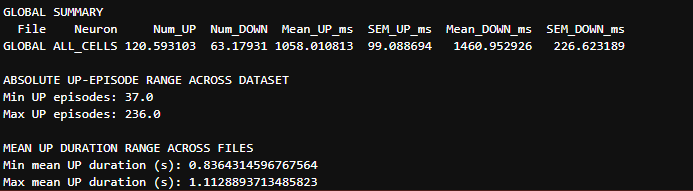

### 3.3) Fraction of cells labeled as Active (i.e., in active episode, UP)
This segment loads each sign matrix and computes the proportion of active neurons using sliding 500 ms windows. 
For each file it measures the average proportion of active cells, peak coactivation, and total time spent above activation thresholds.
Reports global across animals in S1.

In [ ]:
# 3.3)

# sliding window
frame_dt = 1 / FS   # 0.1 s per frame
window_ms = 500 # WINDOW 500ms

# convert window to number of frames
window_frames = max(1, int(round((window_ms / 1000) * FS)))
#print(f"Sliding window = {window_frames} frames ({window_ms} ms)")

rows = []

for f in os.listdir(analysis_folder):
    if not f.endswith("_sign_matrix.npy"):
        continue

    base = f.replace("_sign_matrix.npy", "")
    S = np.load(os.path.join(analysis_folder, f))
    T, N = S.shape

    # build sliding windows of length window_frames
    # shape → (num_windows, window_frames, N)
    num_windows = T - window_frames + 1
    win = np.stack([S[i:i+window_frames] for i in range(num_windows)], axis=0) 
    # any activity in window (per cell)
    win_any = (win == 1).any(axis=1)        # (num_windows, N)
    window_frac = win_any.mean(axis=1) # fraction of cells active at least once per window

    # metrics
    mean_frac = window_frac.mean()
    peak_frac = window_frac.max()
    t30 = (window_frac > 0.30).sum() * frame_dt
    t50 = (window_frac > 0.50).sum() * frame_dt
    t70 = (window_frac > 0.70).sum() * frame_dt # for report

    rows.append({
        "File": base,
        "MeanFrac": mean_frac,
        "PeakFrac": peak_frac,
        "TimeAbove30_s": t30,
        "TimeAbove50_s": t50,
        "TimeAbove70_s": t70 # for report
    })

df = pd.DataFrame(rows)
df.to_csv(os.path.join(analysis_folder, "fraction_active_summary_per_file.csv"), index=False)

# global summary >>>compute
out = {}
for col in ["MeanFrac", "PeakFrac", "TimeAbove30_s", "TimeAbove50_s", "TimeAbove70_s"]: # TimeAbove70_s reported in article 
    vals = df[col].values
    out[f"GlobalMean_{col}"] = np.mean(vals)
    out[f"GlobalSEM_{col}"] = np.std(vals, ddof=1) / np.sqrt(len(vals))

pd.DataFrame([out]).to_csv(os.path.join(analysis_folder, "fraction_active_global_summary.csv"), index=False)

# forgot to print...read the global summary
df_global = pd.read_csv(os.path.join(analysis_folder,"fraction_active_global_summary.csv"))
df_global # GLOBAL SUMMARY (across files for session 1)


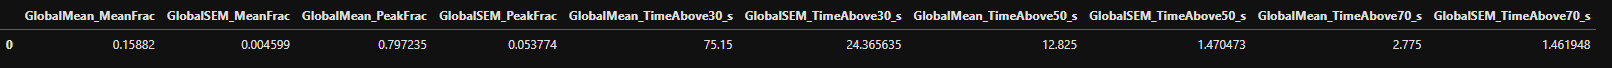

In [ ]:
# Step 3 ends, clear all variables
%reset -f
print("memory clean!")

# ------------------------------------------------------------------------------
## Step 4) Analysis of Co-fluctuating pairs
This section evaluates how many neuron pairs show statistically significant same-direction co-fluctuation, using the Z-score matrices produced on steps above.
For each animal it loads the corresponding file, infers the number of neurons, computes all possible structural pairs, and compares them with the number of pairs that passed filtering and the number that were significant at FDR 0.01. It then calculates group-level mean and SEM across animals.
...see compute_cofluct function in segments above for the rule definition.

In [ ]:
import os, numpy as np, pandas as pd

In [ ]:
# 4. How many neuron pairings show significant cofluctuation, relative to the complete structural pair space?
# takes the summary table produced by earlier analysis and derives per-animal and group-level statistics using all possible neuron pairs, not just filtered pairs.
summary_file = r"...\python_analysis_results\results\day1_directional_summary_surrogate.csv"
analysis_folder = os.path.dirname(summary_file)
df_same = pd.read_csv(summary_file)
summary_file_opp = summary_file.replace("summary_surrogate","summary_surrogate_opp")
df_opp = pd.read_csv(summary_file_opp)
animals = df_same["Animal/File"].tolist()

# significant same-direction + opposite-direction
sig_same = df_same["FDR_q0.01_count"].tolist()
sig_opp  = df_opp["FDR_q0.01_count"].tolist()

# valid co-fluct pairs = significant pairs (Option B)
sig_union = [s + o for s, o in zip(sig_same, sig_opp)]

# structural counts
neuron_counts=[]
for animal in animals:
    zfile=os.path.join(analysis_folder, animal+"_zscore_surrogate.csv")
    N=pd.read_csv(zfile,index_col=0).shape[0]
    neuron_counts.append(N)

all_pairs=[n*(n-1)//2 for n in neuron_counts]
perc_all_union=[(u/a)*100 if a>0 else 0 for u,a in zip(sig_union,all_pairs)]

# AGGREGATE
total_all=sum(all_pairs)
total_sig=sum(sig_union)
overall=(total_sig/total_all*100) if total_all>0 else 0
print("=== AGGREGATE SUMMARY (ANY DIRECTION) ===")
print(f"Total structural pairs: {total_all}") # all possible pairs given that pairs can only exist by animal...
print(f"Total significant pairs: {total_sig}")
print(f"Overall proportion: {overall:.2f}%\n")


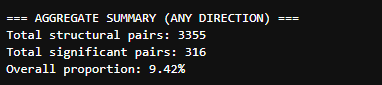

In [ ]:
# Step 4 ends, clear all variables
%reset -f
print("memory clean!")

# ------------------------------------------------------------
## Step 5) Directionality of  co-fluctuation
Whether significant co-fluctuation between neurons is predominantly driven by: Upward calcium-change coincidences (+1/+1) or Downward calcium-change coincidences (–1/–1)
It also quantifies: How strong this bias is per animal. Whether this directional pattern is consistent across animals. What the overall pooled direction is and the Mean ± SEM group statistics for upward vs. downward dominance.
1. What drives the significant co-fluctuation?
 Upward steps, downward steps, or balanced?
2. Is the pattern stable across animals?
 compute per-animal dominance and animal-level mean ± SEM.
3. What is the overall directionality?
 sum across all animals and evaluate the pooled bias.

In [ ]:
import os, numpy as np, pandas as pd
from scipy.stats import norm
from scipy.stats import mannwhitneyu

### 5.1) Construct pairwise significance masks (BH–FDR on surrogate z-scores)
This step converts the surrogate-based z-score matrices (same-direction and opposite-direction co-fluctuation) into binary significance masks at a fixed FDR level (q = 0.01).

In [ ]:
# 5.1) Generate FDR significance masks for SAME and OPP matrices
# Runs once → outputs mask files →  SDI/UDI script will load them.
analysis_folder = r"...\python_analysis_results\results"
FDR = 0.01

def fdr_mask_from_z(zmat, q=0.01):
    N = zmat.shape[0]
    idx = np.triu_indices_from(zmat, k=1)
    zvals = zmat[idx]
    finite = np.isfinite(zvals)
    zvals = zvals[finite]
    if len(zvals)==0:
        return np.zeros_like(zmat, dtype=bool)

    pvals = 1.0 - norm.cdf(zvals)
    order = np.argsort(pvals)
    p_sorted = pvals[order]
    m = len(pvals)
    bh = q * np.arange(1, m+1) / m

    below = p_sorted <= bh
    if not np.any(below):
        mask_flat = np.zeros_like(pvals, dtype=bool)
    else:
        kmax = np.max(np.where(below)[0])
        cutoff = p_sorted[kmax]
        mask_flat = pvals <= cutoff

    # reconstruct full symmetric matrix mask
    full_mask = np.zeros((N, N), dtype=bool)
    full_mask[idx] = mask_flat
    full_mask = full_mask | full_mask.T
    np.fill_diagonal(full_mask, False)

    return full_mask

# RUN over SAME- and OPP-direction Z-score matrices
print("\nGenerating SAME and OPP significance masks...")
files_same = [f for f in os.listdir(analysis_folder)
              if f.endswith("_zscore_surrogate.csv")]
files_opp  = [f for f in os.listdir(analysis_folder)
              if f.endswith("_zscore_surrogate_opp.csv")]

for f_same in files_same:
    base = f_same.replace("_zscore_surrogate.csv", "")
    f_opp = base + "_zscore_surrogate_opp.csv"

    z_same = pd.read_csv(os.path.join(analysis_folder, f_same), index_col=0).values
    z_opp  = pd.read_csv(os.path.join(analysis_folder, f_opp), index_col=0).values

    mask_same = fdr_mask_from_z(z_same, q=FDR)
    mask_opp  = fdr_mask_from_z(z_opp,  q=FDR)

    np.save(os.path.join(analysis_folder, base + "_sigmask_same.npy"), mask_same)
    np.save(os.path.join(analysis_folder, base + "_sigmask_opp.npy"),  mask_opp)

### 5.2) Directionality classification of significant neuron pairs (SDI / UDI)
This step quantifies directional structure of co-fluctuation, restricted strictly to neuron pairs that were significant after surrogate + FDR correction (described above).

computing two normalized directionality indices on significant neuron pairs only.

	​ = coincident positive–positive events
     = coincident negative–negative events​
     = opposite-sign coincidences
     - total of above 3 conditions
#### SDI — Same-vs-Different Index: Measures whether the pair prefers same-direction vs opposite-direction cofluctuation...is a signed synchronization dominance metric.
#### UDI — Up-vs-Down Index: Measures bias within same-direction events....captures polarity asymmetry, not synchrony vs opposition.


In [ ]:
# 5.2) Directionality classification of significant neuron pairs (SDI / UDI)
summary_file = os.path.join(analysis_folder, "day1_directional_summary_surrogate.csv")
df = pd.read_csv(summary_file); animals = df["Animal/File"].tolist()
load = lambda p: pd.read_csv(p, index_col=0).values

SDI_th = 0.5; UDI_th = 0.5
animal_SDI=[]; animal_UDI=[]; animal_label=[]
agg_up=agg_down=agg_opp=agg_none=agg_sig=0; neuron_counts=[]

print("\n=== SDI/UDI DIRECTIONALITY (SIGNIFICANT PAIRS ONLY) ===\n")

for animal in animals:
    up=load(os.path.join(analysis_folder, animal+"_same_up_counts.csv"))
    dn=load(os.path.join(analysis_folder, animal+"_same_down_counts.csv"))
    of=load(os.path.join(analysis_folder, animal+"_oppfrac_obs.csv"))
    sm=np.load(os.path.join(analysis_folder, animal+"_sigmask_same.npy"))
    om=np.load(os.path.join(analysis_folder, animal+"_sigmask_opp.npy"))
    sig = np.triu(sm | om, 1)

    N=up.shape[0]; neuron_counts.append(N)
    SDI_list=[]; UDI_list=[]
    c_up=c_dn=c_op=c_no=0

    for i in range(N):
        for j in range(i+1, N):
            if not sig[i,j]: continue
            agg_sig+=1
            Tup, Tdn = up[i,j], dn[i,j]
            Topp = of[i,j]*(Tup+Tdn+1e-9)
            total = Tup+Tdn+Topp
            if total<=0: c_no+=1; agg_none+=1; continue

            SDI = ((Tup+Tdn)-Topp)/total; SDI_list.append(SDI)
            UDI = (Tup-Tdn)/(Tup+Tdn) if (Tup+Tdn)>0 else np.nan; UDI_list.append(UDI)

            if abs(SDI)<SDI_th: c_no+=1; agg_none+=1; continue
            if SDI<0: c_op+=1; agg_opp+=1; continue
            if UDI>UDI_th: c_up+=1; agg_up+=1
            elif UDI<-UDI_th: c_dn+=1; agg_down+=1
            else: c_no+=1; agg_none+=1

    mSDI, mUDI = np.nanmean(SDI_list), np.nanmean(UDI_list)
    animal_SDI.append(mSDI); animal_UDI.append(mUDI)
    lbl = ("UPWARD" if mSDI>SDI_th and mUDI>UDI_th else
           "DOWNWARD" if mSDI>SDI_th and mUDI<-UDI_th else
           "SAME-DIR (no bias)" if mSDI>SDI_th else
           "OPPOSITE" if mSDI<-SDI_th else "NONE")
    animal_label.append(lbl)

    print(f"{animal}:  SDI={mSDI:.3f}, UDI={mUDI:.3f}, Dir={lbl}")

# pooled
print("\n=== AGGREGATE SUMMARY (ALL ANIMALS) ===")
tot_pairs=sum(n*(n-1)//2 for n in neuron_counts)
p_sig = agg_sig/tot_pairs*100
print(f"Total pairs={tot_pairs}, Significant={agg_sig} ({p_sig:.2f}%)")
tot = agg_up+agg_down+agg_opp+agg_none
print(f"UP={agg_up} ({agg_up/tot*100:.2f}%), DOWN={agg_down} ({agg_down/tot*100:.2f}%), OPP={agg_opp} ({agg_opp/tot*100:.2f}%), NONE={agg_none} ({agg_none/tot*100:.2f}%)")

# group-level mean ± SEM
arrS=np.array(animal_SDI); arrU=np.array(animal_UDI)
mS, sS = np.nanmean(arrS), np.nanstd(arrS, ddof=1)/np.sqrt(len(arrS))
mU, sU = np.nanmean(arrU), np.nanstd(arrU, ddof=1)/np.sqrt(len(arrU))
print("\n=== GROUP-LEVEL (MEAN ± SEM) ===")
print(f"SDI [SDI: biased toward same vs opposite sign]: {mS:.3f} ± {sS:.3f}")
print(f"UDI [UDI: biased toward up vs down] : {mU:.3f} ± {sU:.3f}")

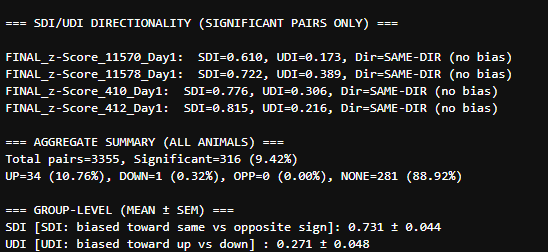


### 5.3) Computing Mutual information for FDR-significant neuron pairs
This step Computes pairwise mutual information (MI) on the episode sign matrix, restricted to neuron pairs that were significant after surrogate testing and FDR.
For each significant pair (from pairwise_MI_significant_pairs.csv), it recomputes SDI and UDI from the same _same_up_counts, _same_down_counts, and _oppfrac_obs matrices,
assigns each pair to UP or NONE using your SDI/UDI thresholds, then compares MI between these two groups (mean MI and Mann–Whitney test).

mutual information: https://www.kaggle.com/code/ryanholbrook/mutual-information

In [ ]:
# MUTUAL INFORMATION FOR SIGNIFICANT PAIRS

MI_results = []
def mi_joint_count(a,b):
    # a,b are sign arrays clipped to {-1,0,+1}, but MI only considers non-zero frames
    v = (a!=0) & (b!=0); a, b = a[v], b[v]
    if len(a)==0: return np.nan
    # joint counts: (+1,+1),(–1,–1),(+1,–1),(–1,+1)
    C = {
        ( 1, 1): np.sum((a== 1)&(b== 1)),
        (-1,-1): np.sum((a==-1)&(b==-1)),
        ( 1,-1): np.sum((a== 1)&(b==-1)),
        (-1, 1): np.sum((a==-1)&(b== 1))
    }
    tot = sum(C.values())
    if tot==0: return np.nan
    pxy = np.array(list(C.values()))/tot
    px  = np.array([np.sum(a== 1), np.sum(a==-1)]) / len(a)
    py  = np.array([np.sum(b== 1), np.sum(b==-1)]) / len(b)
    # expand px,py into 4 joint expectations
    px_exp = np.array([px[0]*py[0], px[1]*py[1], px[0]*py[1], px[1]*py[0]])
    nz = (pxy>0) & (px_exp>0)
    return np.sum(pxy[nz] * np.log2(pxy[nz]/px_exp[nz]))

for animal in animals:
    sign = np.load(os.path.join(analysis_folder, animal+"_sign_matrix.npy"))
    sm   = np.load(os.path.join(analysis_folder, animal+"_sigmask_same.npy"))
    om   = np.load(os.path.join(analysis_folder, animal+"_sigmask_opp.npy"))
    sig  = np.triu(sm | om, 1)

    N = sig.shape[0]
    MI_list=[]

    for i in range(N):
        for j in range(i+1, N):
            if not sig[i,j]: continue
            MI = mi_joint_count(sign[:,i], sign[:,j])
            MI_list.append(MI)
            MI_results.append({"Animal":animal,"i":i,"j":j,"MI":MI})

# convert to DataFrame and save
df_mi = pd.DataFrame(MI_results)
df_mi.to_csv(os.path.join(analysis_folder,"pairwise_MI_significant_pairs.csv"), index=False)

MI_up = []; MI_none = []

for animal in df_mi["Animal"].unique():
    up = load(os.path.join(analysis_folderr, animal+"_same_up_counts.csv"))
    dn = load(os.path.join(analysis_folderr, animal+"_same_down_counts.csv"))
    of = load(os.path.join(analysis_folder, animal+"_oppfrac_obs.csv"))
    sub = df_mi[df_mi["Animal"]==animal]

    for _, row in sub.iterrows():
        i, j = int(row["i"]), int(row["j"])
        Tup, Tdn = up[i,j], dn[i,j]
        Topp = of[i,j]*(Tup+Tdn+1e-9)
        total = Tup+Tdn+Topp
        if total<=0: continue

        SDI = ((Tup+Tdn)-Topp)/total
        UDI = (Tup-Tdn)/(Tup+Tdn) if (Tup+Tdn)>0 else np.nan

        if abs(SDI)<SDI_th:
            label = "NONE"
        elif SDI<0:
            label = "OPP"
        else:
            if UDI>UDI_th:   label="UP"
            elif UDI<-UDI_th: label="DOWN"
            else:            label="NONE"

        if label=="UP":   MI_up.append(row["MI"])
        if label=="NONE": MI_none.append(row["MI"])

MI_up = np.array(MI_up); MI_none = np.array(MI_none)
print(f"n_UP={len(MI_up)}, n_NONE={len(MI_none)}")
print(f"Mean MI_UP={MI_up.mean():.4f}, Mean MI_NONE={MI_none.mean():.4f}")

if len(MI_up) > 0 and len(MI_none) > 0:
    U, p = mannwhitneyu(MI_up, MI_none, alternative="two-sided")
    print(f"Mann–Whitney U={U:.1f}, p={p:.3g}")
else:
    print("Not enough pairs in one group for Mann–Whitney test.")


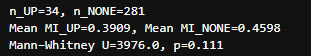